In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
# import geopandas as gpd
import pandas as pd
import seaborn as sns
from scipy.stats import qmc
from ipywidgets import IntProgress

# importeren van ewatercycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

In [2]:
basin_name = "Frans"

# tijdsinterval
start_datum = "2017-01-01"
eind_datum = "2021-12-31"

# route naar shape file
shapefile = Path.home() / "BEP-Julian" / "BEP-Julian" / "Frans_model" / "Frans.shp"

# route naar forcing ERA5 data
forcing_route = Path.home() / "BEP-Julian" / "BEP-Julian" / "Forcing" / "ERA5_2017_2021"/ "work" / "diagnostic" / "script"
forcing_route.mkdir(exist_ok=True)

# route naar hbv 
HBV_model = Path.home() / "BEP-Julian" / "BEP-Julian" / "Frans_model" / "hbv_bmi"
HBV_model.mkdir(exist_ok=True)

# route naar discharge file, van Maxime
discharge_file = Path.home() / "BEP-Julian" / "BEP-Julian" / "Frans_model" / "Frans.csv"

# stroomgebied oppervlakte im km^2
frans_area = 7.638586e+03 

                          Date    Value
9144 2017-01-01 00:00:00+00:00  138.547
9145 2017-01-02 00:00:00+00:00  132.485
9146 2017-01-03 00:00:00+00:00  162.360
9147 2017-01-04 00:00:00+00:00  179.180
9148 2017-01-05 00:00:00+00:00  196.999


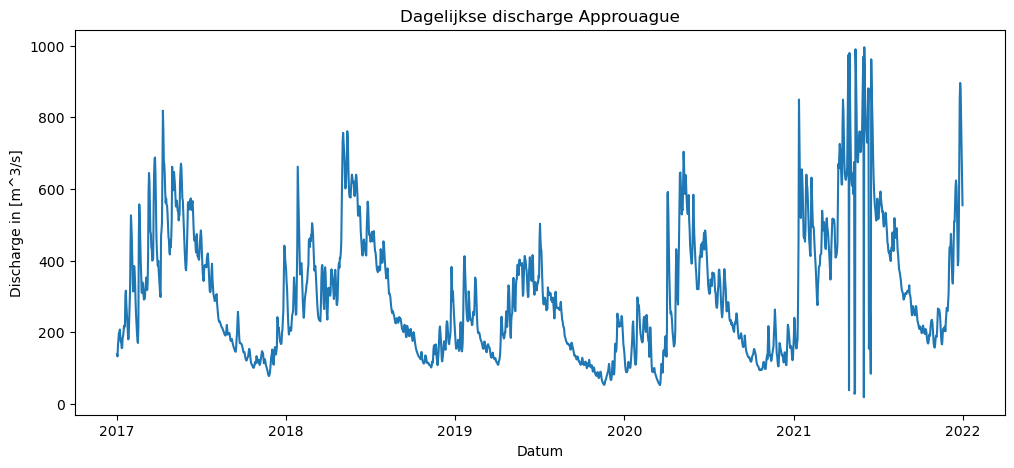

In [3]:
df = pd.read_csv(discharge_file, delimiter=';')
df["Value"] = df["Value"]/1000 # excel formatting van engels naar nederlands. Kan in excel worden opgelost maar ik ben lui
# df = pd.read_csv(discharge_file, delimiter=';', header = 0,  index_col=[0], parse_dates = True)
df.replace(999000, np.nan, inplace=True)
# print(df)

df["Date"] = pd.to_datetime(df["Date"], utc = True)
# print(df)
# print("Max = ",df["Value"].max())

# start_date = pd.to_datetime(start_datum.replace("Z", ""))
# end_date = pd.to_datetime(eind_datum.replace("Z", ""))

start_date = pd.to_datetime(start_datum, utc=True)
end_date = pd.to_datetime(eind_datum, utc=True)

df = df[
    (df["Date"] >= start_date) &
    (df["Date"] <= end_date)
].copy()

start_time_utc = start_date.strftime("%Y-%m-%dT%H:%M:%SZ")
end_time_utc = end_date.strftime("%Y-%m-%dT%H:%M:%SZ")

flow = pd.DataFrame(data=df["Value"].values, index=df["Date"], columns=['Q'])
flow.index = pd.to_datetime(flow.index).tz_localize(None)

print(df.head())

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Value"])
plt.xlabel("Datum")
plt.ylabel("Discharge in [m^3/s]")
plt.title("Dagelijkse discharge Approuague")
plt.show()

In [4]:
df["Date"] = pd.to_datetime(df["Date"]).dt.tz_localize(None)
df["Date"] = df["Date"].dt.normalize()  
print(df)

            Date    Value
9144  2017-01-01  138.547
9145  2017-01-02  132.485
9146  2017-01-03  162.360
9147  2017-01-04  179.180
9148  2017-01-05  196.999
...          ...      ...
10965 2021-12-27  875.271
10966 2021-12-28  799.095
10967 2021-12-29  713.189
10968 2021-12-30  626.093
10969 2021-12-31  554.588

[1826 rows x 2 columns]


In [5]:
start_calibration = '2017-01-01'
end_calibration = '2021-12-31'

In [6]:
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_route)

In [7]:
evap = ERA5_forcing.to_xarray()["evspsblpot"] #units: kg m^-2 s^-1 = mm/s, gesampled per dag
prec = ERA5_forcing.to_xarray()["pr"] #units: kg m^-2 s^-1 = mm/s, gesampled per dag

In [8]:
print(f"The forcing object you created: \n {ERA5_forcing}")

The forcing object you created: 
 start_time='2017-01-01T00:00:00Z' end_time='2021-12-31T00:00:00Z' directory=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/ERA5_2017_2021/work/diagnostic/script') shape=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/ERA5_2017_2021/work/diagnostic/script/Frans.shp') filenames={'pr': 'OBS6_ERA5_reanaly_1_day_pr_2017-2021.nc', 'tas': 'OBS6_ERA5_reanaly_1_day_tas_2017-2021.nc', 'rsds': 'OBS6_ERA5_reanaly_1_day_rsds_2017-2021.nc', 'evspsblpot': 'Derived_Makkink_evspsblpot.nc'}


In [9]:
# Van Ischa om een goede eerste fit te krijgen. Zelf nog 1 maken om te begrijpen wat er gebeurt. 
def RMSE(output, observed, start, end):
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)
    
    output.index = pd.to_datetime(output.index)
    observed.index = pd.to_datetime(observed.index)

    hydro_data = pd.concat([output.reindex(observed.index, method='ffill'), observed], axis=1, keys=['model', 'observation'])
    hydro_data = hydro_data.dropna()
    
    hydro_data = hydro_data[(hydro_data.index > start) & (hydro_data.index < end)]
    
    squarediff = (hydro_data['model'] - hydro_data['observation']) ** 2
    rootMeanSquareDiff = np.sqrt(np.mean(squarediff))
    
    return rootMeanSquareDiff

In [10]:
N = 200 # begin met 200, later voor 2000 gaan 

In [11]:
s_0 = np.array([0,  100,  0,  5,  0])

# Define parameters and their corresponding boundary values 
param_names = ["Imax", "Ce", "Sumax", "Beta", "Pmax", "Tlag", "Kf", "Ks", "FM"]
param_mins = np.array([0, 0.2, 40, 0.5, 0.001, 1, 0.01, 0.0001, 0.0])
param_maxs = np.array([8, 1, 800, 4, 0.3, 10, 0.1, 0.01, 0.000001])

#Fill the parameters array with N random values between each minimum and maximum 
sampler = qmc.LatinHypercube(d=len(param_names))
sample = sampler.random(n=N)
parameters = qmc.scale(sample, param_mins, param_maxs)
print(list(zip(param_names, np.round(parameters[0], decimals=3))))

[('Imax', 2.804), ('Ce', 0.969), ('Sumax', 516.734), ('Beta', 1.191), ('Pmax', 0.017), ('Tlag', 9.912), ('Kf', 0.01), ('Ks', 0.008), ('FM', 0.0)]


In [12]:
def mmday_to_m3s(Q_sim_mmday, frans_area):
    return (Q_sim_mmday * frans_area) / 86.4

In [13]:
ensemble = []

for counter in range(N): 
    ensemble.append(ewatercycle.models.HBVLocal(forcing=ERA5_forcing))
    config_file, _ = ensemble[counter].setup(parameters = parameters[counter],  initial_storage=s_0, cfg_dir = HBV_model)
    ensemble[counter].initialize(config_file)

In [14]:
f = IntProgress(min=0, max=N)
display(f)

# Array to store level of fit values
objectives_RMSE = []

# Loop over ensemble members
for ensembleMember in ensemble:
    Q_m_RMSE = []
    time_RMSE = []
    while ensembleMember.time < ensembleMember.end_time:
        ensembleMember.update()
        discharge_this_timestep = ensembleMember.get_value("Q")
        Q_m_RMSE.append(discharge_this_timestep[0])
        time_RMSE.append(ensembleMember.time_as_datetime)

    # Create DataFrame for model results
    Q_m_RMSE = mmday_to_m3s(np.array(Q_m_RMSE), frans_area)
    discharge_dataframe = pd.DataFrame({'model output': Q_m_RMSE}, index=pd.to_datetime(time_RMSE))
    
    # Calculate the model of best-fit function
    fit_RMSE = RMSE(discharge_dataframe['model output'], flow['Q'], start_calibration, end_calibration)
    objectives_RMSE.append(fit_RMSE)

    # Free up memory
    del Q_m_RMSE, time_RMSE, discharge_dataframe, fit_RMSE
    f.value += 1

# Clean up models to save memory
for ensembleMember in ensemble:
    ensembleMember.finalize()

IntProgress(value=0, max=200)

In [15]:
parameters_RMSE_index = np.argmin(np.array(objectives_RMSE))
if np.min(np.array(objectives_RMSE)) == np.inf:
    print("No real parameter is chosen")

parameters_RMSE = parameters[parameters_RMSE_index]

print(f'The best RMSE parameters are: {list(zip(param_names, np.round(parameters_RMSE, decimals=3)))}')
print(parameters_RMSE)

The best RMSE parameters are: [('Imax', 7.609), ('Ce', 0.306), ('Sumax', 618.137), ('Beta', 0.567), ('Pmax', 0.19), ('Tlag', 8.476), ('Kf', 0.021), ('Ks', 0.006), ('FM', 0.0)]
[7.60894202e+00 3.06086096e-01 6.18136939e+02 5.66671995e-01
 1.90238614e-01 8.47574800e+00 2.08107863e-02 5.78125219e-03
 2.18548004e-07]


In [16]:
#nu zouden de parameters gegenereerd moeten zijn

In [17]:
model = ewatercycle.models.HBV(forcing=ERA5_forcing)

config_file, _ = model.setup(parameters=parameters_RMSE, initial_storages=s_0, cfg_dir=HBV_model)

model.initialize(config_file)
Q_m = []
time = []

while model.time < model.end_time:
    model.update()
    Q_m.append(model.get_value("Q")[0])
    time.append(pd.Timestamp(model.time_as_datetime))

model.finalize()

In [18]:
model_output_mmday = pd.Series(data=Q_m, name="Modelled discharge", index=time)
print(model_output_mmday.max())
model_output_m3s = model_output_mmday * frans_area * 1000 / 86400

observed_output = pd.Series(data=df["Value"].to_numpy(), name="Observed discharge", index=df["Date"])

9.047235690937669


grdc =              Date    Value
9144  2017-01-01  138.547
9145  2017-01-02  132.485
9146  2017-01-03  162.360
9147  2017-01-04  179.180
9148  2017-01-05  196.999
...          ...      ...
10965 2021-12-27  875.271
10966 2021-12-28  799.095
10967 2021-12-29  713.189
10968 2021-12-30  626.093
10969 2021-12-31  554.588

[1826 rows x 2 columns]
model = 2017-01-02 12:00:00      0.000025
2017-01-03 12:00:00      0.068825
2017-01-04 12:00:00      0.359506
2017-01-05 12:00:00      1.075546
2017-01-06 12:00:00      2.413526
                          ...    
2021-12-27 12:00:00    323.814909
2021-12-28 12:00:00    336.350805
2021-12-29 12:00:00    345.928937
2021-12-30 12:00:00    351.351085
2021-12-31 12:00:00    353.798624
Name: Modelled discharge, Length: 1825, dtype: float64


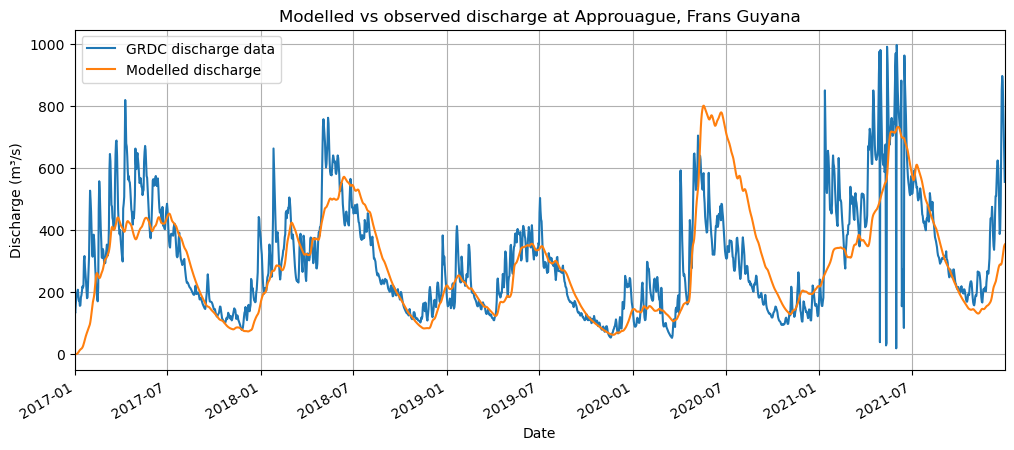

In [19]:
plt.figure(figsize=(12, 5))

q_critical = 500

plt.plot(df["Date"], df["Value"], label = "GRDC discharge data")
model_output_m3s.plot(label="Modelled discharge")
print("grdc = ",df)
print("model =", model_output_m3s)
# plt.axhline(y=q_critical, linestyle=":", label=f'Critical discharge ({q_critical} m³/s', color='black')

plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.title("Modelled vs observed discharge at Approuague, Frans Guyana")
plt.legend()
plt.grid(True)
plt.xlim("2017-01-01", "2021-12-31")

plt.show()